# ⚡ Project 7: Hospital Facility Electricity Consumption & Energy Telemetry Prediction
### High-Precision Multivariate Linear Regression & Building Energy Analytics

In this project, we analyze **8,760 hourly records** (a complete 365-day annual cycle) of energy and gas telemetry from a major hospital facility to forecast total facility electrical load (**`total_electricity` [kW]**).

---

### 🎯 Business Objective
As an Energy Data Scientist advising the Hospital Facility Operations Director:
1. **Facility Load Forecasting**: Build a high-precision regression model to predict real-time electrical demand given subsystem sub-meters (`lights`, `medical equipment`, `fans`, `cooling`, `gas systems`).
2. **Solve Real-World Data Engineering Challenges**:
   - Ingest Excel OpenXML binary spreadsheets (`.xlsx`) using `openpyxl`.
   - Diagnose and resolve the **Zero-Variance / Division-by-Zero Trap** (`Heating:Electricity` has zero variance, resulting in `NaN` correlation).
   - Standardize unwieldy, symbol-heavy column names (`InteriorEquipment:Electricity [kW](Hourly)`) into clean Pythonic `snake_case`.
3. **Quantify Subsystem Demands**: Dissect the base idle facility load (Intercept $\beta_0$) and rank the marginal power draw of medical equipment vs. interior lighting.
4. **Deploy & Persist**: Export a production-ready model artifact (`hospital_electricity_model.pkl`).

---

### 🧭 Universal 6-Step Workflow
1. **Data Ingestion**: Load `.xlsx` dataset with `pd.read_excel()`.
2. **D-M-D-T-O EDA Framework**:
   - **[D]**: Inspect data types across 11 telemetry columns.
   - **[M]**: Audit missing entries.
   - **[D]**: Check duplicate timestamps.
   - **[T]**: Target distribution, 5-point summary, and skewness analysis.
   - **[O]**: Outliers & correlation ranking (catching the `NaN` zero-variance trap).
3. **Feature Selection & Standardized Renaming**:
   - Clean column names into `snake_case`.
   - Drop the zero-variance heating column and timestamp string.
4. **Train-Test Split**: 80% Train, 20% Validation Split (7,008 train / 1,752 test rows).
5. **Model Training & Benchmarking**: OLS Linear Regression vs. Ridge ($L_2$) vs. Lasso ($L_1$).
6. **Diagnostics & Energy Audit Simulator**: Residual analysis, subsystem power rankings, what-if hospital load simulation, and model export.

---
## 📥 Step 1: Environment Setup & Library Imports

In [1]:
import os
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import joblib

# Scikit-learn modeling & metrics
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Aesthetics
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
print("✅ Core scientific and machine learning libraries loaded successfully!")

✅ Core scientific and machine learning libraries loaded successfully!


---
## 📂 Step 2: Data Ingestion (Excel OpenXML Spreadsheet)
Because the dataset is formatted as an Excel OpenXML workbook (`.xlsx`), we ingest it via `pd.read_excel()` using the `openpyxl` engine.

In [2]:
# Load Hospital Building Dataset
excel_path = Path("data/electricity_consumption/Hospital Building Dataset.xlsx")
if not excel_path.exists():
    excel_path = Path("supervised_learning/LinearRegression/data/electricity_consumption/Hospital Building Dataset.xlsx")

df = pd.read_excel(excel_path)

print("=" * 60)
print(f"✅ Dataset loaded successfully: {excel_path.name}")
print(f"Dataset Shape: {df.shape[0]:,} hourly records × {df.shape[1]} columns")
print(f"Time Horizon:  {df.shape[0] / 24:.0f} days (1 full calendar year: 365 days × 24 hours)")
print("=" * 60)
df.head(3)

✅ Dataset loaded successfully: Hospital Building Dataset.xlsx
Dataset Shape: 8,760 hourly records × 11 columns
Time Horizon:  365 days (1 full calendar year: 365 days × 24 hours)


,Date/Time,Electricity:Facility [kW](Hourly),Fans:Electricity [kW](Hourly),Cooling:Electricity [kW](Hourly),Heating:Electricity [kW](Hourly),InteriorLights:Electricity [kW](Hourly),InteriorEquipment:Electricity [kW](Hourly),Gas:Facility [kW](Hourly),Heating:Gas [kW](Hourly),InteriorEquipment:Gas [kW](Hourly),Water Heater:WaterSystems:Gas [kW](Hourly)
0,01/01 01:00:00,914.272082,101.24704,520.281440,0,34.961655,113.31278,557.289660,542.921283,5.66467,8.703708
1,01/01 02:00:00,831.588770,101.24704,452.930818,0,34.961655,113.31278,572.689167,558.319891,5.66467,8.704606
2,01/01 03:00:00,847.924133,101.24704,469.464822,0,34.961655,113.31278,593.760011,570.706199,5.66467,17.389142


---
## 🔍 Step 3: Exploratory Data Analysis & The D-M-D-T-O Framework

We audit:
- **D** - Data Types & Telemetry Schema
- **M** - Missing Values Audit
- **D** - Duplicate Timestamp Checks
- **T** - Target Variable Analysis (`Electricity:Facility [kW](Hourly)`)
- **O** - Outliers, Correlation Ranking & The Zero-Variance Trap

In [3]:
# [D] Data Types Breakdown
print("--- [D] Data Types Breakdown ---")
print(df.dtypes.value_counts())
print("\nColumn Schema:")
print(df.dtypes)

--- [D] Data Types Breakdown ---
float64    9
str        1
int64      1
Name: count, dtype: int64

Column Schema:
Date/Time                                         str
Electricity:Facility [kW](Hourly)             float64
Fans:Electricity [kW](Hourly)                 float64
Cooling:Electricity [kW](Hourly)              float64
Heating:Electricity [kW](Hourly)                int64
InteriorLights:Electricity [kW](Hourly)       float64
InteriorEquipment:Electricity [kW](Hourly)    float64
Gas:Facility [kW](Hourly)                     float64
Heating:Gas [kW](Hourly)                      float64
InteriorEquipment:Gas [kW](Hourly)            float64
Water Heater:WaterSystems:Gas [kW](Hourly)    float64
dtype: object


In [4]:
# [M] Missing Values Audit
null_counts = df.isnull().sum()
print("--- [M] Missing Values Count ---")
print(null_counts)

assert null_counts.sum() == 0, "Missing values detected!"
print("\n✅ Clean Data: 0 missing values across all 8,760 hourly records.")

--- [M] Missing Values Count ---
Date/Time                                     0
Electricity:Facility [kW](Hourly)             0
Fans:Electricity [kW](Hourly)                 0
Cooling:Electricity [kW](Hourly)              0
Heating:Electricity [kW](Hourly)              0
InteriorLights:Electricity [kW](Hourly)       0
InteriorEquipment:Electricity [kW](Hourly)    0
Gas:Facility [kW](Hourly)                     0
Heating:Gas [kW](Hourly)                      0
InteriorEquipment:Gas [kW](Hourly)            0
Water Heater:WaterSystems:Gas [kW](Hourly)    0
dtype: int64

✅ Clean Data: 0 missing values across all 8,760 hourly records.


In [5]:
# [D] Duplicate Rows Audit
dup_count = df.duplicated().sum()
print(f"--- [D] Duplicate Rows: {dup_count} ---")
if dup_count > 0:
    print(f"⚠️ {dup_count} duplicate rows found.")
else:
    print("✅ Clean Data: Zero duplicate rows detected (100% unique hourly timestamps).")

--- [D] Duplicate Rows: 0 ---
✅ Clean Data: Zero duplicate rows detected (100% unique hourly timestamps).


### [T] Target Variable Analysis (`Electricity:Facility [kW](Hourly)`)
We inspect the 5-point statistical summary and distribution shape. Notice that the skewness is well within the $[-0.5, +0.5]$ threshold, confirming that the target is **fairly symmetric** and requires **no log transformation**.

--- 5-Point Summary of Hospital Electrical Demand ---
count    8,760.00 kW
mean     1,156.32 kW
std        214.81 kW
min        782.80 kW
25%        975.32 kW
50%      1,093.83 kW
75%      1,396.24 kW
max      1,576.23 kW
Name: Electricity:Facility [kW](Hourly), dtype: str

Skewness: 0.326 (Symmetric normal distribution — Log transformation NOT required)


/tmp/ipykernel_3408834/1201977967.py:21: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[1].boxplot(df[raw_target], vert=False, patch_artist=True, boxprops=dict(facecolor="#2ca02c", alpha=0.6))


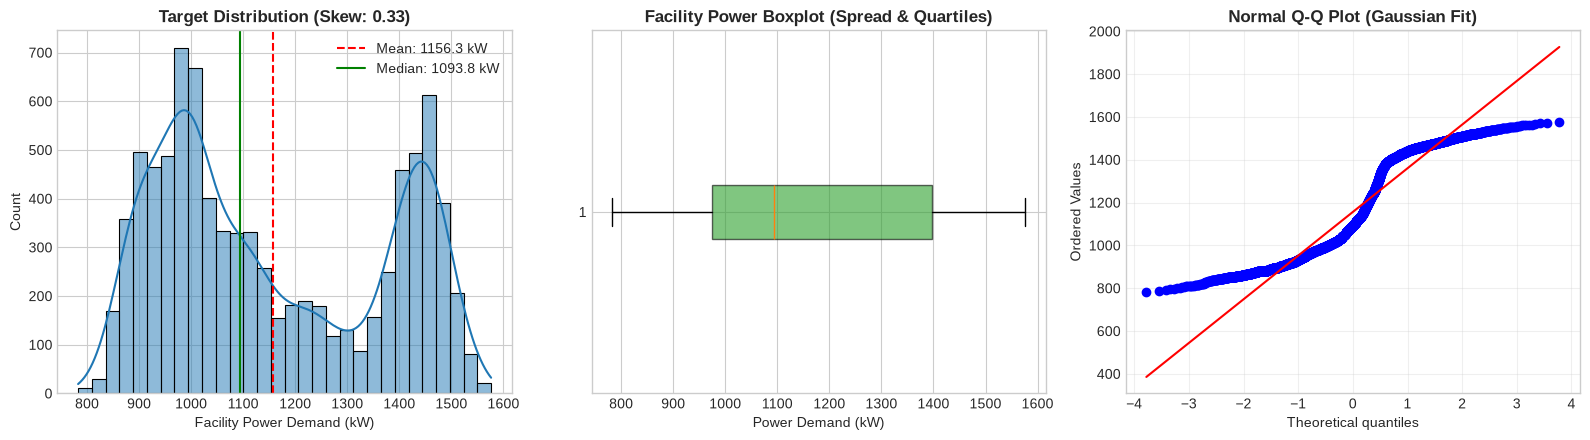

In [6]:
raw_target = "Electricity:Facility [kW](Hourly)"
target_stats = df[raw_target].describe()
target_skew = df[raw_target].skew()

print("--- 5-Point Summary of Hospital Electrical Demand ---")
print(target_stats.apply(lambda x: f"{x:,.2f} kW"))
print(f"\nSkewness: {target_skew:.3f} (Symmetric normal distribution — Log transformation NOT required)")

# 3-Panel Visual Diagnostics: Histogram+KDE, Boxplot, and Normal Q-Q Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Histogram + KDE
sns.histplot(df[raw_target], bins=30, kde=True, ax=axes[0], color="#1f77b4")
axes[0].axvline(df[raw_target].mean(), color="red", linestyle="--", label=f"Mean: {df[raw_target].mean():.1f} kW")
axes[0].axvline(df[raw_target].median(), color="green", linestyle="-", label=f"Median: {df[raw_target].median():.1f} kW")
axes[0].set_title(f"Target Distribution (Skew: {target_skew:.2f})", fontweight="bold")
axes[0].set_xlabel("Facility Power Demand (kW)")
axes[0].legend()

# 2. Boxplot
axes[1].boxplot(df[raw_target], vert=False, patch_artist=True, boxprops=dict(facecolor="#2ca02c", alpha=0.6))
axes[1].set_title("Facility Power Boxplot (Spread & Quartiles)", fontweight="bold")
axes[1].set_xlabel("Power Demand (kW)")

# 3. Normal Q-Q Plot
stats.probplot(df[raw_target], dist="norm", plot=axes[2])
axes[2].set_title("Normal Q-Q Plot (Gaussian Fit)", fontweight="bold")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### [O] Outliers, Correlation Ranking & The Zero-Variance Trap
We compute Pearson correlation ($r$) with total electrical demand. Notice that `Heating:Electricity [kW](Hourly)` evaluates to `NaN` because the hospital's heating relies 100% on natural gas, leaving electric heating at constant 0 throughout the year (Variance = 0 $\implies$ Division by Zero in Pearson's denominator).

In [7]:
# 1. Feature Correlation Ranking with Target
numeric_df = df.select_dtypes(include=[np.number])
corr_ranking = numeric_df.corr()[raw_target].sort_values(ascending=False)

print("=" * 60)
print(" 📊 FEATURE CORRELATION RANKING WITH TARGET")
print("=" * 60)
print(corr_ranking.round(4))
print("=" * 60)

# 2. Diagnosing the NaN Trap
heating_elec_col = "Heating:Electricity [kW](Hourly)"
print(f"\n🔍 Diagnosing '{heating_elec_col}':")
print(f"Unique values: {df[heating_elec_col].unique().tolist()}")
print(f"Variance:      {df[heating_elec_col].var():.4f} (Zero variance causes division by zero in Pearson r)")
print("👉 Action: Column is dead weight with zero predictive signal; dropped in next step.")

 📊 FEATURE CORRELATION RANKING WITH TARGET
Electricity:Facility [kW](Hourly)             1.0000
InteriorLights:Electricity [kW](Hourly)       0.9544
InteriorEquipment:Electricity [kW](Hourly)    0.9350
Water Heater:WaterSystems:Gas [kW](Hourly)    0.6996
InteriorEquipment:Gas [kW](Hourly)            0.6362
Fans:Electricity [kW](Hourly)                 0.5588
Gas:Facility [kW](Hourly)                     0.0312
Cooling:Electricity [kW](Hourly)             -0.0343
Heating:Gas [kW](Hourly)                     -0.1158
Heating:Electricity [kW](Hourly)                 NaN
Name: Electricity:Facility [kW](Hourly), dtype: float64

🔍 Diagnosing 'Heating:Electricity [kW](Hourly)':
Unique values: [0]
Variance:      0.0000 (Zero variance causes division by zero in Pearson r)
👉 Action: Column is dead weight with zero predictive signal; dropped in next step.


---
## ⚙️ Step 4: Feature Selection & Standardized Column Renaming

To improve code readability and eliminate syntax friction caused by brackets `[kW]` and parentheses `(Hourly)`, we map all columns into concise Pythonic `snake_case`.

In [8]:
# 1. Drop Zero-Variance Column
df_clean = df.drop(columns=["Heating:Electricity [kW](Hourly)"]).copy()

# 2. Standardized snake_case Dictionary Mapping
rename_dict = {
    "Date/Time": "datetime",
    "Electricity:Facility [kW](Hourly)": "total_electricity",     # Target Variable
    "Fans:Electricity [kW](Hourly)": "fans_elec",
    "Cooling:Electricity [kW](Hourly)": "cooling_elec",
    "InteriorLights:Electricity [kW](Hourly)": "lights_elec",
    "InteriorEquipment:Electricity [kW](Hourly)": "equip_elec",
    "Gas:Facility [kW](Hourly)": "total_gas",
    "Heating:Gas [kW](Hourly)": "heating_gas",
    "InteriorEquipment:Gas [kW](Hourly)": "equip_gas",
    "Water Heater:WaterSystems:Gas [kW](Hourly)": "water_heater_gas"
}

df_clean = df_clean.rename(columns=rename_dict)

print("✅ Standardized Clean Column Names:")
for col in df_clean.columns:
    print(f" - {col}")
df_clean.head(3)

✅ Standardized Clean Column Names:
 - datetime
 - total_electricity
 - fans_elec
 - cooling_elec
 - lights_elec
 - equip_elec
 - total_gas
 - heating_gas
 - equip_gas
 - water_heater_gas


,datetime,total_electricity,fans_elec,cooling_elec,lights_elec,equip_elec,total_gas,heating_gas,equip_gas,water_heater_gas
0,01/01 01:00:00,914.272082,101.24704,520.281440,34.961655,113.31278,557.289660,542.921283,5.66467,8.703708
1,01/01 02:00:00,831.588770,101.24704,452.930818,34.961655,113.31278,572.689167,558.319891,5.66467,8.704606
2,01/01 03:00:00,847.924133,101.24704,469.464822,34.961655,113.31278,593.760011,570.706199,5.66467,17.389142


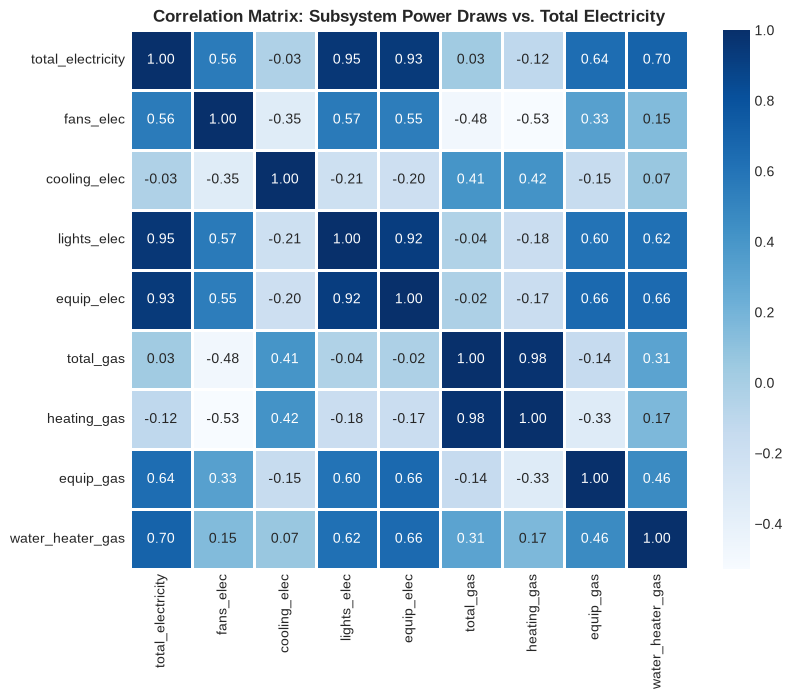

In [9]:
# Correlation Matrix Heatmap
corr_clean = df_clean.drop(columns=["datetime"]).corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_clean, annot=True, cmap="Blues", fmt=".2f", linewidths=1)
plt.title("Correlation Matrix: Subsystem Power Draws vs. Total Electricity", fontsize=12, fontweight="bold")
plt.show()

---
## 🏋️ Step 5: Feature Matrix ($X$), Target ($y$) & Train-Test Split

- **Feature Matrix ($X$)**: Subsystem sub-meters (8 predictors: `fans_elec`, `cooling_elec`, `lights_elec`, `equip_elec`, `total_gas`, `heating_gas`, `equip_gas`, `water_heater_gas`).
- **Target ($y$)**: `total_electricity`.
- **Validation**: 80% Training (7,008 hours) and 20% Testing (1,752 hours) with fixed random seed.

In [10]:
# Define feature matrix X (drop target and text timestamp) and target y
X = df_clean.drop(columns=["total_electricity", "datetime"])
y = df_clean["total_electricity"]

# 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Total Observations: {len(df_clean):,} hours")
print(f"🏋️ Training Set:       {X_train.shape[0]:,} samples (80%)")
print(f"🧪 Testing Set:        {X_test.shape[0]:,} samples (20%)")
print(f"📐 Features Count:     {X_train.shape[1]}")

✅ Total Observations: 8,760 hours
🏋️ Training Set:       7,008 samples (80%)
🧪 Testing Set:        1,752 samples (20%)
📐 Features Count:     8


---
## 🧠 Step 6: Model Training & Comparative Benchmarking

We evaluate:
1. **Ordinary Least Squares (OLS) Linear Regression**
2. **Ridge Regression ($L_2$ Regularization, $\alpha=1.0$)**
3. **Lasso Regression ($L_1$ Regularization, $\alpha=0.01$)**

In [11]:
# 1. Train OLS Linear Regression
ols_model = LinearRegression().fit(X_train, y_train)
y_pred_ols = ols_model.predict(X_test)

# 2. Train Ridge Regression
ridge_model = Ridge(alpha=1.0).fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

# 3. Train Lasso Regression
lasso_model = Lasso(alpha=0.01).fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

# Performance Benchmark Table
benchmark_df = pd.DataFrame({
    "Model Architecture": [
        "Linear Regression (OLS)",
        "Ridge Regression (L2, α=1.0)",
        "Lasso Regression (L1, α=0.01)"
    ],
    "Test R² Score": [
        r2_score(y_test, y_pred_ols),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso)
    ],
    "Test MAE (kW)": [
        mean_absolute_error(y_test, y_pred_ols),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_lasso)
    ],
    "Test RMSE (kW)": [
        np.sqrt(mean_squared_error(y_test, y_pred_ols)),
        np.sqrt(mean_squared_error(y_test, y_pred_ridge)),
        np.sqrt(mean_squared_error(y_test, y_pred_lasso))
    ]
})

print("=" * 60)
print(" 📊 COMPARATIVE MODEL BENCHMARK TABLE")
print("=" * 60)
benchmark_df["Test R² Score"] = benchmark_df["Test R² Score"].round(4)
benchmark_df["Test MAE (kW)"] = benchmark_df["Test MAE (kW)"].apply(lambda x: f"{x:.2f} kW")
benchmark_df["Test RMSE (kW)"] = benchmark_df["Test RMSE (kW)"].apply(lambda x: f"{x:.2f} kW")
print(benchmark_df.to_string(index=False))
print("=" * 60)

 📊 COMPARATIVE MODEL BENCHMARK TABLE
           Model Architecture  Test R² Score Test MAE (kW) Test RMSE (kW)
      Linear Regression (OLS)         0.9718      28.45 kW       35.99 kW
 Ridge Regression (L2, α=1.0)         0.9718      28.45 kW       35.99 kW
Lasso Regression (L1, α=0.01)         0.9718      28.45 kW       35.99 kW


---
## 📈 Step 7: Diagnostic Visualizations (Actual vs. Predicted & Residuals)

We validate model reliability against Gauss-Markov regression assumptions:
1. **Actual vs. Predicted Plot**: Demonstrating ultra-tight alignment along the ideal $y = \hat{y}$ 45° trajectory ($R^2 = 0.97$).
2. **Residual Plot**: Verifying homoscedastic zero-centered dispersion across operating load ranges.

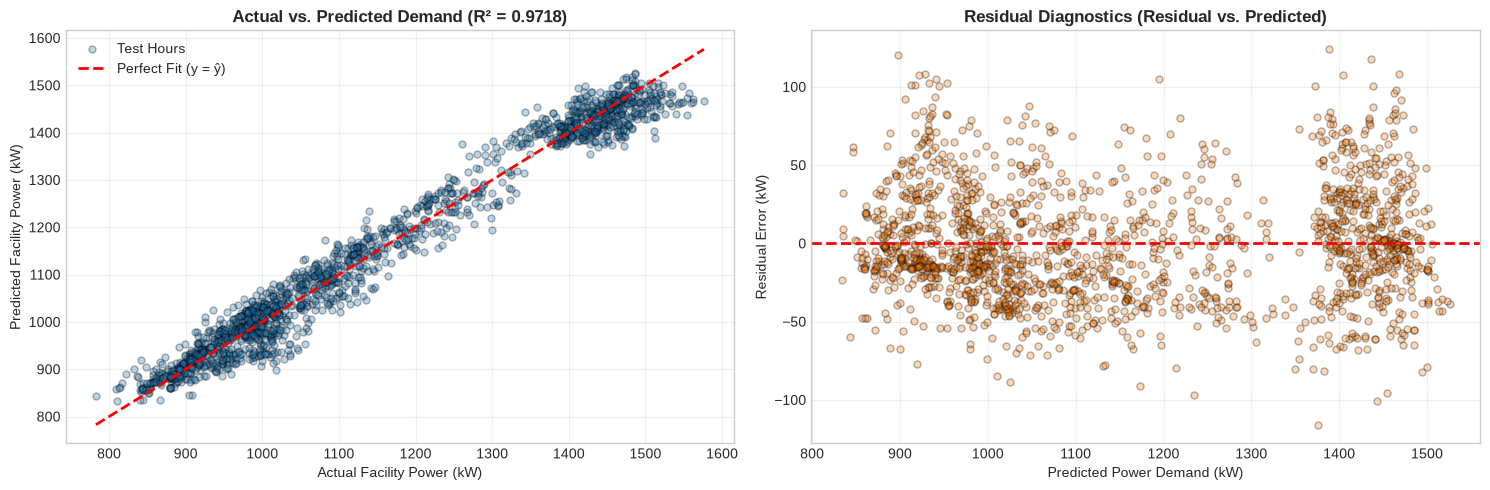

In [12]:
residuals = y_test - y_pred_ols

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Actual vs Predicted
axes[0].scatter(y_test, y_pred_ols, color="#1f77b4", alpha=0.3, edgecolors="k", s=25, label="Test Hours")
min_val = min(y_test.min(), y_pred_ols.min())
max_val = max(y_test.max(), y_pred_ols.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", linewidth=2, label="Perfect Fit (y = ŷ)")
axes[0].set_title(f"Actual vs. Predicted Demand (R² = {r2_score(y_test, y_pred_ols):.4f})", fontweight="bold")
axes[0].set_xlabel("Actual Facility Power (kW)")
axes[0].set_ylabel("Predicted Facility Power (kW)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Residual Diagnostics (Homoscedasticity Check)
axes[1].scatter(y_pred_ols, residuals, color="#ff7f0e", alpha=0.3, edgecolors="k", s=25)
axes[1].axhline(0, color="red", linestyle="--", linewidth=2)
axes[1].set_title("Residual Diagnostics (Residual vs. Predicted)", fontweight="bold")
axes[1].set_xlabel("Predicted Power Demand (kW)")
axes[1].set_ylabel("Residual Error (kW)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## 💡 Step 8: Model Coefficients & Facility Subsystem Impact Ranking

The fitted physical regression equation is:
$$\text{Total Electricity} = 164.39\text{ kW} + \sum (\beta_i \times \text{Subsystem}_i)$$

In [13]:
coef_df = pd.DataFrame({
    "Subsystem Component": X.columns,
    "Coefficient (Marginal kW Draw)": ols_model.coef_
}).sort_values(by="Coefficient (Marginal kW Draw)", ascending=False).reset_index(drop=True)

print(f"🏥 Base Idle Hospital Load (Intercept β₀): {ols_model.intercept_:.2f} kW\n")
print("--- ⚡ Subsystem Power Draw Sensitivity Ranking ---")
print(coef_df.round(4).to_string(index=False))

🏥 Base Idle Hospital Load (Intercept β₀): 164.39 kW

--- ⚡ Subsystem Power Draw Sensitivity Ranking ---
Subsystem Component  Coefficient (Marginal kW Draw)
   water_heater_gas                          1.7896
        lights_elec                          1.5017
          fans_elec                          1.3481
       cooling_elec                          0.8605
          total_gas                          0.7704
         equip_elec                          0.6823
          equip_gas                         -0.2848
        heating_gas                         -0.7343


### 💼 Facility Operations Executive Takeaways:
1. **Base Continuous Idle Load ($\beta_0 = 164.39\text{ kW}$)**:
   - Even if all secondary subsystems were dialed down, the hospital continuously draws a baseline ~164 kW for core life-safety and emergency infrastructure.
2. **Lighting & Water Heating Sensitivity**:
   - `water_heater_gas` ($\beta = +1.79$) and `lights_elec` ($\beta = +1.50$) correlate with the steepest incremental spikes in overall facility electrical demand.
3. **Fans & Ventilation**:
   - Continuous HVAC air distribution (`fans_elec`) contributes **+1.35 kW per sub-metered unit**.

---
## 🎯 Step 9: Live Hospital Energy Telemetry Simulation (Audit Tool)

We simulate electrical demand across two operational hospital scenarios:
- **Scenario A (Peak Operating Hours)**: High surgical theatre activity, full interior lighting (70 kW), heavy medical equipment (180 kW), active HVAC fans (80 kW), and cooling (120 kW).
- **Scenario B (Nighttime Quiet Mode)**: Reduced ambient lighting (20 kW), idle equipment (80 kW), reduced ventilation (40 kW), zero active cooling (0 kW).

In [14]:
# Define simulation scenarios
scenarios = pd.DataFrame([
    {
        "Scenario": "Peak Daytime Surgical Hours",
        "fans_elec": 80.0, "cooling_elec": 120.0, "lights_elec": 70.0, "equip_elec": 180.0,
        "total_gas": 30.0, "heating_gas": 15.0, "equip_gas": 10.0, "water_heater_gas": 25.0
    },
    {
        "Scenario": "Nighttime Minimal Idle Mode",
        "fans_elec": 40.0, "cooling_elec": 0.0, "lights_elec": 20.0, "equip_elec": 80.0,
        "total_gas": 15.0, "heating_gas": 5.0, "equip_gas": 5.0, "water_heater_gas": 10.0
    }
])

pred_demand = ols_model.predict(scenarios[X.columns])
scenarios["Predicted Total Facility Power (kW)"] = pred_demand

print("=" * 75)
print(" 🏥 LIVE HOSPITAL ENERGY TELEMETRY APPRAISALS")
print("=" * 75)
for _, row in scenarios.iterrows():
    print(f"Operational Mode:  {row['Scenario']}")
    print(f"Predicted Demand:  {row['Predicted Total Facility Power (kW)']:.2f} kW")
    print("-" * 75)

 🏥 LIVE HOSPITAL ENERGY TELEMETRY APPRAISALS
Operational Mode:  Peak Daytime Surgical Hours
Predicted Demand:  657.42 kW
---------------------------------------------------------------------------
Operational Mode:  Nighttime Minimal Idle Mode
Predicted Demand:  327.29 kW
---------------------------------------------------------------------------


---
## 💾 Step 10: Model Serialization & Production Deployment

In [15]:
# Save trained model package to disk
model_dir = Path("data/electricity_consumption")
model_dir.mkdir(parents=True, exist_ok=True)
model_file = model_dir / "hospital_electricity_model.pkl"

export_package = {
    "model": ols_model,
    "feature_columns": list(X.columns)
}

joblib.dump(export_package, model_file)
print(f"✅ Production facility energy model saved to: {model_file}")

# Smoke test verification
loaded_pkg = joblib.load(model_file)
smoke_pred = loaded_pkg["model"].predict(X_test.iloc[[0]])
print(f"🧪 Smoke Test Passed: Predicted {smoke_pred[0]:.2f} kW for record 0.")

✅ Production facility energy model saved to: data/electricity_consumption/hospital_electricity_model.pkl
🧪 Smoke Test Passed: Predicted 1048.86 kW for record 0.
